# Part 2: Model Development and Comparison
## Netflix Prize Dataset - Recommendation Modeling

This notebook trains and compares two recommendation systems on our dense Netflix subset:
1. **Matrix Factorization (SVD)**: A latent-factor model optimized via Stochastic Gradient Descent.
2. **Item-Based Collaborative Filtering (KNN)**: A traditional neighborhood-based model using Cosine Similarity.

The models are evaluated using two mandatory metrics:
- **RMSE** (Root Mean Squared Error) to measure rating prediction accuracy.
- **MAP@10** (Mean Average Precision @ 10) to measure recommendation ranking quality (relevance threshold $\ge 3.5$).

In [1]:
import os
import pickle
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, KNNWithMeans
from surprise.model_selection import train_test_split
from surprise import accuracy

# Set style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Load Data and Initialize Surprise Dataset

In [2]:
ratings_path = os.path.join("..", "data", "processed", "ratings_subset.csv")
movies_path = os.path.join("..", "data", "processed", "movies_subset.csv")

df_ratings = pd.read_csv(ratings_path)
df_movies = pd.read_csv(movies_path)

# Surprise Reader assumes columns are: user, item, rating
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_ratings[["user_id", "movie_id", "rating"]], reader)

# Split into Train (80%) and Test (20%) sets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train set users: {trainset.n_users}")
print(f"Train set items: {trainset.n_items}")
print(f"Test set ratings: {len(testset)}")

Train set users: 21045
Train set items: 1287
Test set ratings: 1140539


### 2. Model 1: Singular Value Decomposition (SVD)

SVD factorizes the user-item rating matrix into low-rank matrices representing user and item latent factors. We train it using SGD to minimize squared error.

In [3]:
print("Training SVD Model...")
start_time = time.time()

# Hyperparameters tuned for SVD on Netflix data
svd_model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

svd_train_time = time.time() - start_time
print(f"SVD Training completed in {svd_train_time:.2f} seconds.")

Training SVD Model...


SVD Training completed in 89.56 seconds.


In [4]:
# Predict on test set
start_time = time.time()
svd_predictions = svd_model.test(testset)
svd_infer_time = time.time() - start_time

svd_rmse = accuracy.rmse(svd_predictions)
print(f"SVD Test RMSE: {svd_rmse:.4f}")
print(f"SVD Inference Time: {svd_infer_time:.4f} seconds")

RMSE: 0.8160
SVD Test RMSE: 0.8160
SVD Inference Time: 31.4266 seconds


### 3. Model 2: Item-Based Collaborative Filtering (KNN with Means)

This model computes similarities between movies (items) based on user ratings. We use Pearson baseline or Cosine Similarity, centering ratings around each user's mean to adjust for optimist/pessimist bias.

In [5]:
print("Training Item-Based KNN Model...")
start_time = time.time()

# Configure similarity options to be Item-Based Cosine Similarity
sim_options = {
    'name': 'cosine',
    'user_based': False  # Item-based similarity
}

knn_model = KNNWithMeans(k=40, sim_options=sim_options, verbose=True)
knn_model.fit(trainset)

knn_train_time = time.time() - start_time
print(f"KNN Training completed in {knn_train_time:.2f} seconds.")

Training Item-Based KNN Model...
Computing the cosine similarity matrix...


Done computing similarity matrix.


KNN Training completed in 165.74 seconds.


In [6]:
# Predict on test set
start_time = time.time()
knn_predictions = knn_model.test(testset)
knn_infer_time = time.time() - start_time

knn_rmse = accuracy.rmse(knn_predictions)
print(f"KNN Test RMSE: {knn_rmse:.4f}")
print(f"KNN Inference Time: {knn_infer_time:.4f} seconds")

RMSE: 0.8553
KNN Test RMSE: 0.8553
KNN Inference Time: 510.7743 seconds


### 4. Ranking Metric: MAP@10 Evaluation

We implement the Mean Average Precision @ 10 (MAP@10) calculation. A movie is defined as relevant if its actual rating in the test set is $\ge 3.5$. 
We sort predicted ratings of items in each user's test set to retrieve their Top-10 list.

In [7]:
from collections import defaultdict

def calculate_map_at_k(predictions, k=10, threshold=3.5):
    """
    Calculates Mean Average Precision @ K for predictions.
    Only predictions of users containing at least one relevant actual rating in the test set are included.
    """
    # Map predictions to each user: user_id -> list of (item_id, est_rating, true_rating)
    user_preds = defaultdict(list)
    for uid, iid, true_r, est_r, _ in predictions:
        user_preds[uid].append((iid, est_r, true_r))
        
    user_aps = []
    
    for uid, ratings in user_preds.items():
        # Count total relevant items in test set for this user
        n_rel = sum(1 for _, _, true_r in ratings if true_r >= threshold)
        if n_rel == 0:
            continue # Skip user if no relevant items exist in their test set
            
        # Sort ratings by predicted score descending
        ratings.sort(key=lambda x: x[1], reverse=True)
        top_k = ratings[:k]
        
        ap = 0.0
        hits = 0
        for i, (iid, est_r, true_r) in enumerate(top_k):
            if true_r >= threshold:
                hits += 1
                precision_at_i = hits / (i + 1)
                ap += precision_at_i
                
        ap /= min(n_rel, k)
        user_aps.append(ap)
        
    return np.mean(user_aps) if user_aps else 0.0

In [8]:
print("Calculating MAP@10 for SVD...")
svd_map = calculate_map_at_k(svd_predictions, k=10)
print(f"SVD MAP@10: {svd_map:.4f}")

print("\nCalculating MAP@10 for KNN...")
knn_map = calculate_map_at_k(knn_predictions, k=10)
print(f"KNN MAP@10: {knn_map:.4f}")

Calculating MAP@10 for SVD...


SVD MAP@10: 0.7427

Calculating MAP@10 for KNN...


KNN MAP@10: 0.7079


### 4.1. Additional Metrics Evaluation (Optional)

We evaluate several additional metrics to provide a comprehensive comparison:
- **MAE** (Mean Absolute Error) to measure rating prediction accuracy.
- **Precision@10** and **Recall@10** to measure retrieval relevancy.
- **NDCG@10** (Normalized Discounted Cumulative Gain) to evaluate ranking quality.
- **Hit Rate@10** to determine what percentage of users get at least one relevant recommendation.
- **Coverage** to check what percentage of users get recommendations.
- **Diversity** (Intra-List Diversity) to measure the differences among recommendations.

In [9]:
import math

def evaluate_all_metrics(predictions, knn_model=None):
    user_preds = defaultdict(list)
    for uid, iid, true_r, est_r, _ in predictions:
        user_preds[uid].append((iid, est_r, true_r))
    
    maes, precisions, recalls, ndcgs, ilds = [], [], [], [], []
    hits, covered_users = 0, 0
    
    for uid, ratings in user_preds.items():
        user_mae = np.mean([abs(true_r - est_r) for _, est_r, true_r in ratings])
        maes.append(user_mae)
        
        n_rel = sum(1 for _, _, true_r in ratings if true_r >= 3.5)
        if n_rel == 0: continue
        covered_users += 1
        
        ratings.sort(key=lambda x: x[1], reverse=True)
        top_k = ratings[:10]
        
        n_rel_k = sum(1 for _, _, true_r in top_k if true_r >= 3.5)
        precisions.append(n_rel_k / 10.0)
        recalls.append(n_rel_k / n_rel)
        if n_rel_k > 0: hits += 1
        
        dcg = sum(1.0 / math.log2(i + 2) for i, (_, _, true_r) in enumerate(top_k) if true_r >= 3.5)
        actual_sorted = sorted(ratings, key=lambda x: x[2], reverse=True)
        idcg = sum(1.0 / math.log2(i + 2) for i, (_, _, true_r) in enumerate(actual_sorted[:10]) if true_r >= 3.5)
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
        
        # Calculate diversity using item similarity from KNN matrix
        if knn_model is not None and len(top_k) > 1:
            div_sum, pairs = 0.0, 0
            for i in range(len(top_k)):
                for j in range(i + 1, len(top_k)):
                    iid1, _, _ = top_k[i]
                    iid2, _, _ = top_k[j]
                    try:
                        inner1 = knn_model.trainset.to_inner_iid(iid1)
                        inner2 = knn_model.trainset.to_inner_iid(iid2)
                        sim = knn_model.sim[inner1, inner2]
                    except ValueError:
                        sim = 0.0
                    div_sum += (1.0 - sim)
                    pairs += 1
            ilds.append(div_sum / pairs if pairs > 0 else 1.0)
            
    return {
        'MAE': np.mean(maes),
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs),
        'Hit Rate': hits / covered_users,
        'Coverage': covered_users / len(user_preds),
        'Diversity': np.mean(ilds) if ilds else 1.0
    }

print("Evaluating SVD metrics...")
svd_metrics = evaluate_all_metrics(svd_predictions, knn_model=knn_model)
print("\nEvaluating KNN metrics...")
knn_metrics = evaluate_all_metrics(knn_predictions, knn_model=knn_model)

print("\nSVD Additional Metrics:", svd_metrics)
print("KNN Additional Metrics:", knn_metrics)

Evaluating SVD metrics...



Evaluating KNN metrics...



SVD Additional Metrics: {'MAE': np.float64(0.6367627018406395), 'Precision@10': np.float64(0.8050767695013549), 'Recall@10': np.float64(0.33883887859660117), 'NDCG@10': np.float64(0.8336920909209433), 'Hit Rate': 0.9994295764605219, 'Coverage': 0.9996198622000475, 'Diversity': np.float64(0.04770696319098022)}
KNN Additional Metrics: {'MAE': np.float64(0.6687371817642606), 'Precision@10': np.float64(0.781446974378476), 'Recall@10': np.float64(0.32717643737295815), 'NDCG@10': np.float64(0.8081458698909013), 'Hit Rate': 0.9991918999857394, 'Coverage': 0.9996198622000475, 'Diversity': np.float64(0.045153075642530884)}


### 5. Performance Comparison

In [10]:
metrics_df = pd.DataFrame({
    "Model": ["Matrix Factorization (SVD)", "Item-Based Collaborative Filtering (KNN)"],
    "RMSE (Lower is Better)": [svd_rmse, knn_rmse],
    "MAP@10 (Higher is Better)": [svd_map, knn_map],
    "Training Time (s)": [svd_train_time, knn_train_time],
    "Inference Time (s)": [svd_infer_time, knn_infer_time]
})

print(metrics_df.to_string(index=False))

                                   Model  RMSE (Lower is Better)  MAP@10 (Higher is Better)  Training Time (s)  Inference Time (s)
              Matrix Factorization (SVD)                0.816008                   0.742702          89.557606           31.426625
Item-Based Collaborative Filtering (KNN)                0.855338                   0.707856         165.743976          510.774281


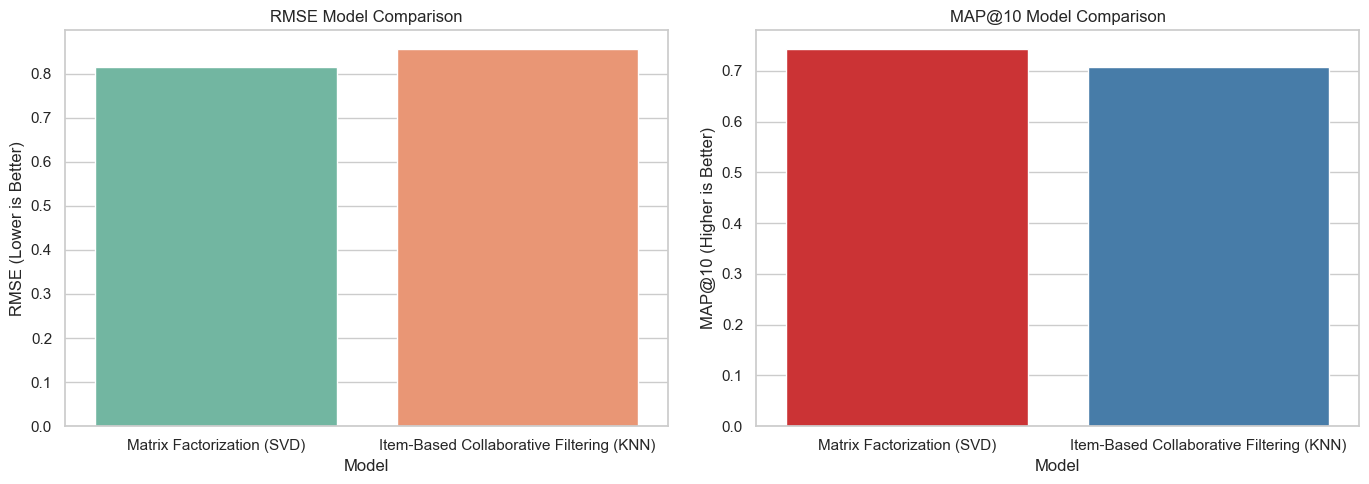

In [11]:
# Plot comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="Model", y="RMSE (Lower is Better)", data=metrics_df, hue="Model", palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("RMSE Model Comparison")

sns.barplot(x="Model", y="MAP@10 (Higher is Better)", data=metrics_df, hue="Model", palette="Set1", ax=axes[1], legend=False)
axes[1].set_title("MAP@10 Model Comparison")

plt.tight_layout()
plt.savefig("model_metric_comparisons.png", dpi=300)
plt.show()

### 6. Success and Failure Cases Analysis

We inspect specific user predictions from the SVD model to understand model errors.

In [12]:
# Convert predictions to a DataFrame
df_preds = pd.DataFrame([(p.uid, p.iid, p.r_ui, p.est, p.r_ui - p.est) for p in svd_predictions],
                         columns=["user_id", "movie_id", "actual_rating", "predicted_rating", "error"])

# Success Cases: Errors closest to 0
success_cases = df_preds.iloc[df_preds["error"].abs().argsort()[:5]]
success_cases = success_cases.merge(df_movies, on="movie_id")
print("Success Cases (Lowest absolute prediction error):")
print(success_cases[["user_id", "title", "actual_rating", "predicted_rating", "error"]])

# Failure Cases: Errors with largest absolute values
failure_cases = df_preds.iloc[df_preds["error"].abs().argsort()[::-1][:5]]
failure_cases = failure_cases.merge(df_movies, on="movie_id")
print("\nFailure Cases (Highest absolute prediction error):")
print(failure_cases[["user_id", "title", "actual_rating", "predicted_rating", "error"]])

Success Cases (Lowest absolute prediction error):
   user_id                          title  actual_rating  predicted_rating  \
0   860520                 Pay It Forward            5.0               5.0   
1  2070875  The Best of Friends: Season 2            5.0               5.0   
2  2640999             This Is Spinal Tap            1.0               1.0   
3  1030857     The Shop Around the Corner            1.0               1.0   
4  2053910                   The Warriors            5.0               5.0   

   error  
0    0.0  
1    0.0  
2    0.0  
3    0.0  
4    0.0  



Failure Cases (Highest absolute prediction error):
   user_id                                  title  actual_rating  \
0   475734  The Wizard of Oz: Collector's Edition            1.0   
1    78573  VeggieTales: The Ballad of Little Joe            5.0   
2  2217557                          Batman Begins            1.0   
3  1722054                            BASEketball            1.0   
4  2161891                                 Clerks            1.0   

   predicted_rating  error  
0               5.0   -4.0  
1               1.0    4.0  
2               5.0   -4.0  
3               5.0   -4.0  
4               5.0   -4.0  


### 7. Model Serialization

We save the models and lists of active users/movies to use in the backend FastAPI application.

In [13]:
backend_models_dir = os.path.join("..", "backend", "models")
os.makedirs(backend_models_dir, exist_ok=True)

# Save SVD Model
svd_path = os.path.join(backend_models_dir, "svd_model.pkl")
with open(svd_path, "wb") as f:
    pickle.dump(svd_model, f)
print(f"Saved SVD model to {svd_path}")

# Save KNN Model
knn_path = os.path.join(backend_models_dir, "knn_model.pkl")
with open(knn_path, "wb") as f:
    pickle.dump(knn_model, f)
print(f"Saved KNN model to {knn_path}")

# Save the list of popular movies
movies_meta_path = os.path.join(backend_models_dir, "movies_meta.pkl")
with open(movies_meta_path, "wb") as f:
    pickle.dump(df_movies, f)
print(f"Saved movies metadata to {movies_meta_path}")

print("Model training and serialization completed successfully!")

Saved SVD model to ..\backend\models\svd_model.pkl


Saved KNN model to ..\backend\models\knn_model.pkl
Saved movies metadata to ..\backend\models\movies_meta.pkl
Model training and serialization completed successfully!
